In [1]:
import os

# Correct path with your spelling
dataset_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/archive'

# Check what's inside
print("=== Contents of brain_tumour_ai ===")
for item in os.listdir(dataset_path):
    print(item)

=== Contents of brain_tumour_ai ===
.DS_Store
Training
Testing


Categories: ['glioma', 'meningioma', 'pituitary', 'notumor']



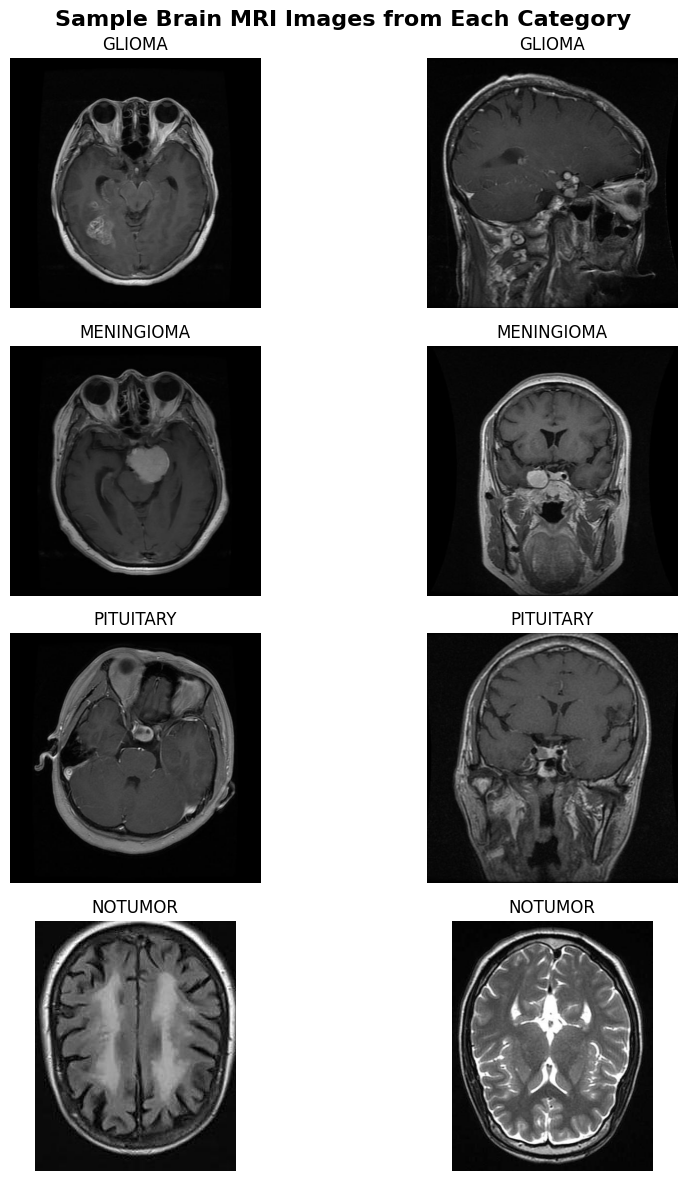


=== IMAGE DIMENSIONS CHECK ===
glioma: (512, 512, 3) (Height × Width × Channels)
meningioma: (512, 512, 3) (Height × Width × Channels)
pituitary: (512, 512, 3) (Height × Width × Channels)
notumor: (251, 201, 3) (Height × Width × Channels)


In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# Set dataset path
train_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/archive/Training'

# Define categories in order
categories = ['glioma', 'meningioma', 'pituitary', 'notumor']
print(f"Categories: {categories}\n")

# Display 2 sample images from each category
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle('Sample Brain MRI Images from Each Category', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(train_path, category)
    images = os.listdir(category_path)[:2]  # Get first 2 images

    for j, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{category.upper()}', fontsize=12)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Check image dimensions from each category
print("\n=== IMAGE DIMENSIONS CHECK ===")
for category in categories:
    category_path = os.path.join(train_path, category)
    sample_img_name = os.listdir(category_path)[0]
    sample_img_path = os.path.join(category_path, sample_img_name)
    sample_img = cv2.imread(sample_img_path)
    print(f"{category}: {sample_img.shape} (Height × Width × Channels)")

In [3]:
import os
import cv2

train_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/archive/Training'
categories = ['glioma', 'meningioma', 'pituitary', 'notumor']

print("=== CHECKING 10 RANDOM IMAGES PER CATEGORY ===\n")

for category in categories:
    category_path = os.path.join(train_path, category)
    images = os.listdir(category_path)[:10]  # Check first 10

    sizes = []
    for img_name in images:
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        sizes.append(img.shape[:2])  # (height, width)

    # Check if all same size
    unique_sizes = set(sizes)
    print(f"{category}:")
    print(f"  Unique sizes found: {unique_sizes}")
    print(f"  Consistent: {'✓ Yes' if len(unique_sizes) == 1 else '✗ No'}\n")


=== CHECKING 10 RANDOM IMAGES PER CATEGORY ===

glioma:
  Unique sizes found: {(512, 512)}
  Consistent: ✓ Yes

meningioma:
  Unique sizes found: {(512, 512)}
  Consistent: ✓ Yes

pituitary:
  Unique sizes found: {(512, 512), (225, 225)}
  Consistent: ✗ No

notumor:
  Unique sizes found: {(217, 232), (225, 225), (630, 630), (228, 235), (824, 755), (449, 359), (251, 201), (257, 196), (282, 230)}
  Consistent: ✗ No



In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# STEP 1: Define paths
train_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/archive/Training'
test_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/archive/Testing'

# STEP 2: Set image parameters
IMG_SIZE = 224  # Standard size for medical imaging
BATCH_SIZE = 32  # Process 32 images at a time (memory efficient)

# STEP 3: Create Data Generators

# Training Data Generator (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize: divide all pixels by 255 (0-255 → 0-1)
    rotation_range=15,        # Randomly rotate images up to 15 degrees
    width_shift_range=0.1,    # Randomly shift images horizontally by 10%
    height_shift_range=0.1,   # Randomly shift images vertically by 10%
    shear_range=0.1,          # Randomly shear (slant) images
    zoom_range=0.1,           # Randomly zoom in/out by 10%
    horizontal_flip=True,     # Randomly flip images horizontally (brain symmetry)
    fill_mode='nearest'       # Fill empty pixels after transformations
)

# Testing Data Generator (NO augmentation - just normalize)
test_datagen = ImageDataGenerator(
    rescale=1./255            # Only normalize, no augmentation for testing
)

# STEP 4: Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),  # Resize all to 224×224
    batch_size=BATCH_SIZE,
    class_mode='categorical',          # Multi-class classification (4 classes)
    shuffle=True                       # Randomly shuffle for better training
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                      # Don't shuffle test data (for evaluation)
)

# STEP 5: Check what we created
print("=== DATA PIPELINE CREATED ===\n")
print(f"Training samples: {train_generator.samples}")
print(f"Testing samples: {test_generator.samples}")
print(f"Number of classes: {train_generator.num_classes}")
print(f"Class labels: {train_generator.class_indices}")
print(f"\nImage shape after preprocessing: ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"Batch size: {BATCH_SIZE}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
=== DATA PIPELINE CREATED ===

Training samples: 5600
Testing samples: 1600
Number of classes: 4
Class labels: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Image shape after preprocessing: (224, 224, 3)
Batch size: 32


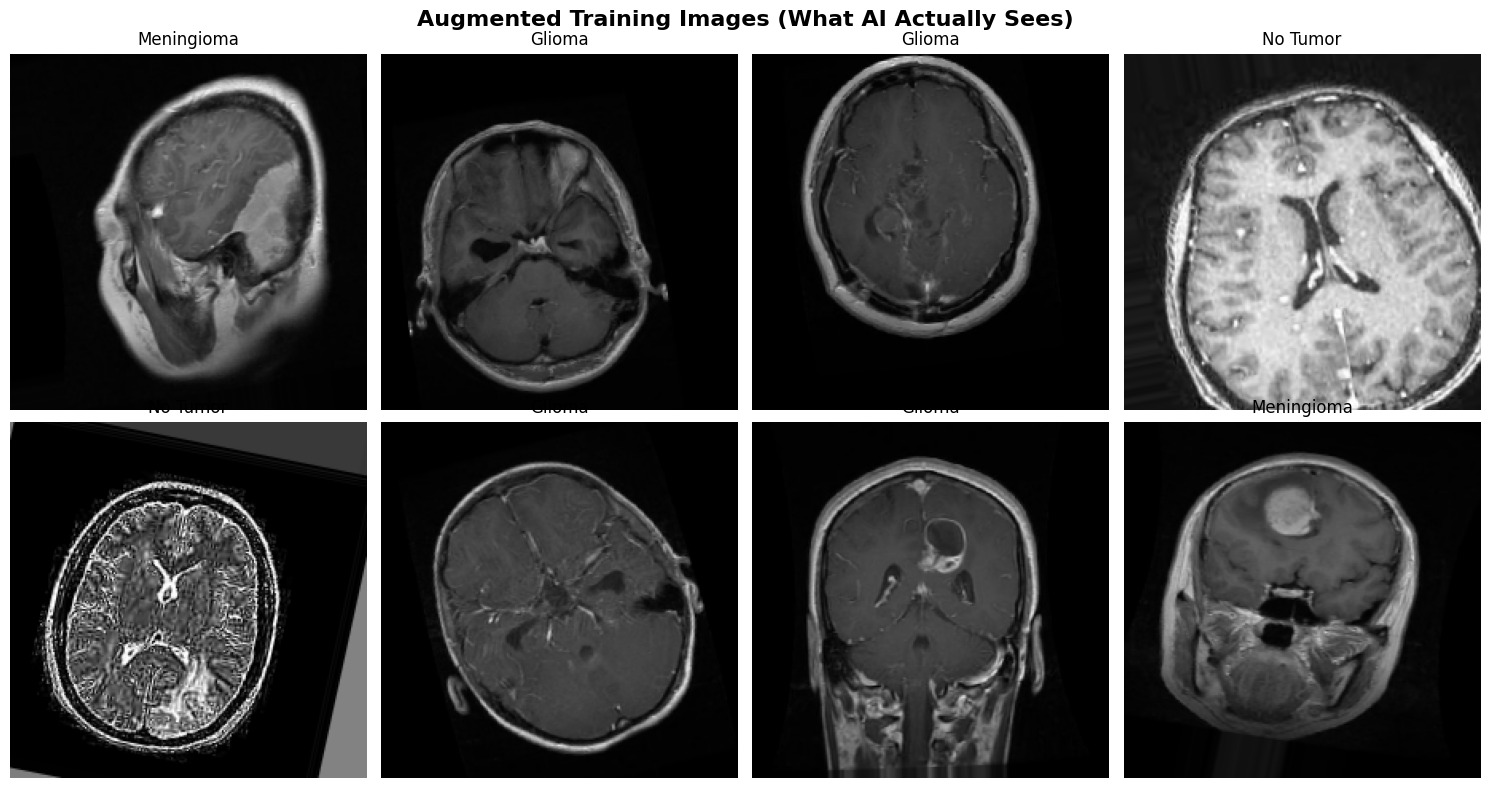


=== WHAT YOU'RE SEEING ===
• Images are resized to 224×224
• Pixel values normalized (0-1 range)
• Random rotations, flips, zooms applied
• Each epoch will show DIFFERENT variations of same images

This prevents overfitting (memorization)!


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of augmented training images
sample_batch, sample_labels = next(train_generator)

# Display 8 augmented images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Augmented Training Images (What AI Actually Sees)', fontsize=16, fontweight='bold')

class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

for i in range(8):
    ax = axes[i // 4, i % 4]

    # Display image
    ax.imshow(sample_batch[i])

    # Get the class label (which class has highest probability)
    label_idx = np.argmax(sample_labels[i])
    class_name = class_names[label_idx]

    ax.set_title(f'{class_name}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n=== WHAT YOU'RE SEEING ===")
print("• Images are resized to 224×224")
print("• Pixel values normalized (0-1 range)")
print("• Random rotations, flips, zooms applied")
print("• Each epoch will show DIFFERENT variations of same images")
print("\nThis prevents overfitting (memorization)!")

In [6]:
import numpy as np

# Get one full batch (32 images)
sample_batch, sample_labels = next(train_generator)

# Count each class in this batch
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
label_indices = np.argmax(sample_labels, axis=1)  # Convert one-hot to class numbers

print("=== CLASS DISTRIBUTION IN ONE BATCH (32 images) ===\n")
for i, class_name in enumerate(class_names):
    count = np.sum(label_indices == i)
    print(f"{class_name}: {count} images ({count/32*100:.1f}%)")

print(f"\nTotal images in batch: {len(label_indices)}")
print("\n💡 This is just ONE random batch.")
print("Over full training, all classes get equal exposure (1,400 each)!")

=== CLASS DISTRIBUTION IN ONE BATCH (32 images) ===

Glioma: 8 images (25.0%)
Meningioma: 12 images (37.5%)
No Tumor: 6 images (18.8%)
Pituitary: 6 images (18.8%)

Total images in batch: 32

💡 This is just ONE random batch.
Over full training, all classes get equal exposure (1,400 each)!


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Create the model
model = Sequential([

    # BLOCK 1: Learn basic features (edges, textures)
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # BLOCK 2: Learn more complex patterns
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # BLOCK 3: Learn high-level features (tumor shapes)
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # BLOCK 4: Even deeper features
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Flatten: Convert 3D feature maps to 1D vector
    Flatten(),

    # DENSE LAYERS: Decision making
    Dense(512, activation='relu'),
    Dropout(0.5),  # Randomly drop 50% of connections (prevents overfitting)

    Dense(256, activation='relu'),
    Dropout(0.5),

    # OUTPUT LAYER: 4 classes with probabilities
    Dense(4, activation='softmax')  # Outputs probabilities for each class
])

# Display architecture
model.summary()

/Users/tayseerfarooq/Desktop/brain-tumour-ai/ml_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,812,292 (37.43 MB)

 Trainable params: 9,811,588 (37.43 MB)

 Non-trainable params: 704 (2.75 KB)

In [8]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # How fast the AI learns
    loss='categorical_crossentropy',        # How we measure mistakes
    metrics=['accuracy']                    # Track accuracy during training
)

print("✅ Model compiled successfully!")
print("\n=== COMPILATION SETTINGS ===")
print("• Optimizer: Adam (adaptive learning rate)")
print("• Learning Rate: 0.0001 (conservative, stable)")
print("• Loss Function: Categorical Crossentropy (for multi-class)")
print("• Metrics: Accuracy (% of correct predictions)")

✅ Model compiled successfully!

=== COMPILATION SETTINGS ===
• Optimizer: Adam (adaptive learning rate)
• Learning Rate: 0.0001 (conservative, stable)
• Loss Function: Categorical Crossentropy (for multi-class)
• Metrics: Accuracy (% of correct predictions)


In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

print("=" * 60)
print("🚀 STARTING TRAINING")
print("=" * 60)
print(f"Training images: {train_generator.samples}")
print(f"Testing images: {test_generator.samples}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch: {train_generator.samples // BATCH_SIZE}")
print("=" * 60)

# Callbacks: Smart helpers during training

# EarlyStopping: Stops training if model stops improving (prevents wasting time)
early_stop = EarlyStopping(
    monitor='val_accuracy',      # Watch test accuracy
    patience=5,                   # Wait 5 epochs before stopping
    restore_best_weights=True,    # Keep the best version
    verbose=1
)

# ReduceLROnPlateau: Reduces learning rate if stuck (helps fine-tune)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',           # Watch test loss
    factor=0.5,                   # Cut learning rate in half
    patience=3,                   # Wait 3 epochs before reducing
    min_lr=0.00001,              # Don't go below this
    verbose=1
)

# Start training!
start_time = time.time()

history = model.fit(
    train_generator,              # Training data
    epochs=20,                    # Maximum 20 cycles through data
    validation_data=test_generator,  # Test on unseen data each epoch
    callbacks=[early_stop, reduce_lr],  # Use smart helpers
    verbose=1                     # Show progress
)

end_time = time.time()
training_time = (end_time - start_time) / 60

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)
print(f"⏱️  Training time: {training_time:.2f} minutes")
print(f"📊 Final training accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"📊 Final test accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 60)


🚀 STARTING TRAINING
Training images: 5600
Testing images: 1600
Batch size: 32
Steps per epoch: 175
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 104s 579ms/step - accuracy: 0.5484 - loss: 1.3264 - val_accuracy: 0.2500 - val_loss: 2.5268 - learning_rate: 1.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 103s 588ms/step - accuracy: 0.6514 - loss: 0.9067 - val_accuracy: 0.3738 - val_loss: 2.5942 - learning_rate: 1.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 104s 595ms/step - accuracy: 0.6832 - loss: 0.8184 - val_accuracy: 0.7125 - val_loss: 0.7665 - learning_rate: 1.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 103s 590ms/step - accuracy: 0.7234 - loss: 0.7272 - val_accuracy: 0.7525 - val_loss: 0.8318 - learning_rate: 1.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 105s 597ms/step - accuracy: 0.7495 - loss: 0.6648 - val_accuracy: 0.6988 - val_loss: 1.1715 - learning_rate: 1.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7603 - loss: 0.6444
Epoch 6: Redu

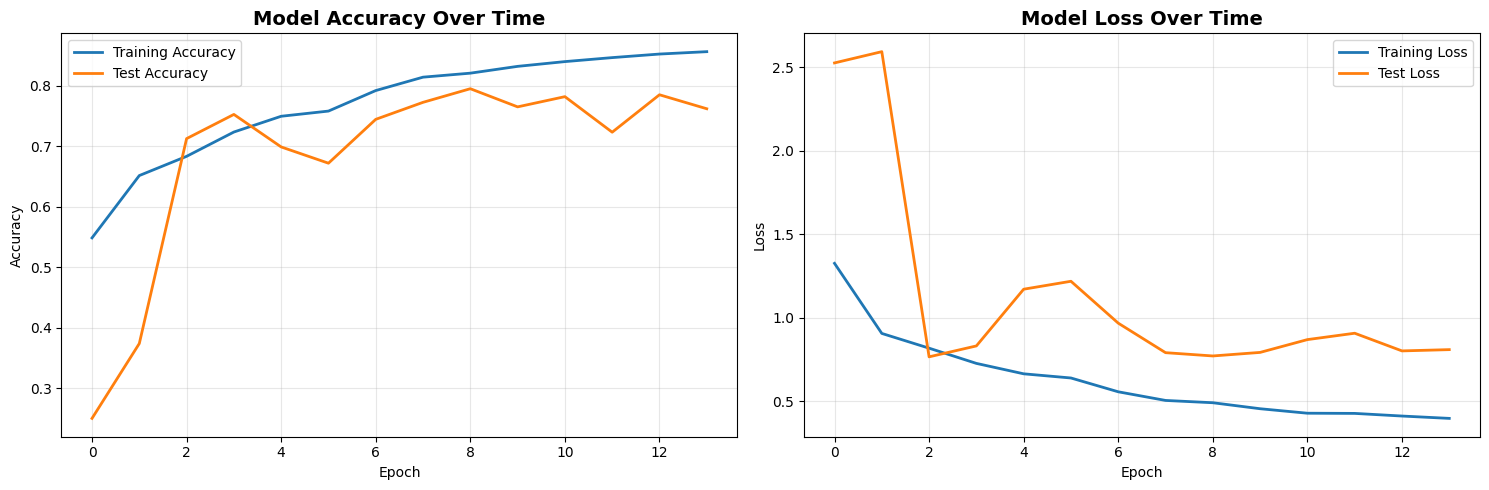


📊 WHAT TO LOOK FOR:
• Both accuracies should increase over time
• Both losses should decrease over time
• Training and Test lines should be close (not diverging)
• If Test accuracy stops improving but Training keeps going = Overfitting


In [20]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy over epochs
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Test Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Loss over epochs
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Test Loss', linewidth=2)
ax2.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 WHAT TO LOOK FOR:")
print("• Both accuracies should increase over time")
print("• Both losses should decrease over time")
print("• Training and Test lines should be close (not diverging)")
print("• If Test accuracy stops improving but Training keeps going = Overfitting")

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

print("🔧 Building improved model with Transfer Learning...")

# Load pre-trained MobileNetV2 (trained on ImageNet - millions of images)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,           # Remove the top classification layer
    weights='imagenet'            # Use pre-trained weights
)

# Freeze the base model (don't retrain it initially)
base_model.trainable = False

# Build new model on top
model_v2 = Sequential([
    base_model,                               # Pre-trained feature extractor
    GlobalAveragePooling2D(),                 # Reduce dimensions
    Dense(256, activation='relu'),            # Our custom layers
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')            # 4 tumor classes
])

# Compile with slightly higher learning rate (we're only training the top)
model_v2.compile(
    optimizer=Adam(learning_rate=0.001),      # 10x higher than before
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Improved model ready!")
model_v2.summary()

🔧 Building improved model with Transfer Learning...
✅ Improved model ready!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time

# Save best model automatically
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

print("🚀 Training improved model...")
start_time = time.time()

history_v2 = model_v2.fit(
    train_generator,
    epochs=15,                                 # Fewer epochs needed
    validation_data=test_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

end_time = time.time()
print(f"\n✅ Training complete! Time: {(end_time - start_time) / 60:.2f} minutes")
print(f"Final test accuracy: {history_v2.history['val_accuracy'][-1]*100:.2f}%")

🚀 Training improved model...
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6395 - loss: 0.8991
Epoch 1: val_accuracy improved from None to 0.73500, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 194ms/step - accuracy: 0.7470 - loss: 0.6617 - val_accuracy: 0.7350 - val_loss: 0.7629 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8374 - loss: 0.4351
Epoch 2: val_accuracy improved from 0.73500 to 0.77438, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step - accuracy: 0.8395 - loss: 0.4278 - val_accuracy: 0.7744 - val_loss: 0.6635 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8515 - loss: 0.3957
Epoch 3: val_accuracy did not improve from 0.77438
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.8541 - loss: 0.3870 - val_accuracy: 0.7669 - val_loss: 0.6652 - learning_rate: 0.0010
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8662 - loss: 0.3412
Epoch 4: val_accuracy improved from 0.77438 to 0.78875, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 205ms/step - accuracy: 0.8668 - loss: 0.3470 - val_accuracy: 0.7887 - val_loss: 0.6153 - learning_rate: 0.0010
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8633 - loss: 0.3527
Epoch 5: val_accuracy improved from 0.78875 to 0.83312, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - accuracy: 0.8745 - loss: 0.3320 - val_accuracy: 0.8331 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8750 - loss: 0.3168
Epoch 6: val_accuracy did not improve from 0.83312
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step - accuracy: 0.8820 - loss: 0.3024 - val_accuracy: 0.8156 - val_loss: 0.5840 - learning_rate: 0.0010
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8981 - loss: 0.2833
Epoch 7: val_accuracy did not improve from 0.83312
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 190ms/step - accuracy: 0.8954 - loss: 0.2803 - val_accuracy: 0.8056 - val_loss: 0.6332 - learning_rate: 0.0010
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9066 - loss: 0.2652
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: val_accuracy did not improve from 0.83312
175/175 ━━━━━━━━━━━━━━━━━


Epoch 9: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 193ms/step - accuracy: 0.9112 - loss: 0.2342 - val_accuracy: 0.8450 - val_loss: 0.5189 - learning_rate: 5.0000e-04
Epoch 10/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9139 - loss: 0.2321
Epoch 10: val_accuracy did not improve from 0.84500
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 193ms/step - accuracy: 0.9127 - loss: 0.2349 - val_accuracy: 0.8288 - val_loss: 0.5338 - learning_rate: 5.0000e-04
Epoch 11/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9261 - loss: 0.1989
Epoch 11: val_accuracy improved from 0.84500 to 0.85062, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 192ms/step - accuracy: 0.9229 - loss: 0.2116 - val_accuracy: 0.8506 - val_loss: 0.5578 - learning_rate: 5.0000e-04
Epoch 12/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9150 - loss: 0.2168
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 12: val_accuracy did not improve from 0.85062
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 192ms/step - accuracy: 0.9193 - loss: 0.2076 - val_accuracy: 0.8350 - val_loss: 0.5978 - learning_rate: 5.0000e-04
Epoch 13/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9284 - loss: 0.1921
Epoch 13: val_accuracy did not improve from 0.85062
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 191ms/step - accuracy: 0.9255 - loss: 0.1950 - val_accuracy: 0.8381 - val_loss: 0.5978 - learning_rate: 2.5000e-04
Epoch 14/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9353 - loss: 0.1805
Epoch 14: val_accuracy improved from 0.85062 to 0.86187, 


Epoch 14: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 192ms/step - accuracy: 0.9295 - loss: 0.1923 - val_accuracy: 0.8619 - val_loss: 0.5100 - learning_rate: 2.5000e-04
Epoch 15/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9410 - loss: 0.1731
Epoch 15: val_accuracy improved from 0.86187 to 0.86437, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.9370 - loss: 0.1788 - val_accuracy: 0.8644 - val_loss: 0.4975 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 15.

✅ Training complete! Time: 8.64 minutes
Final test accuracy: 86.44%


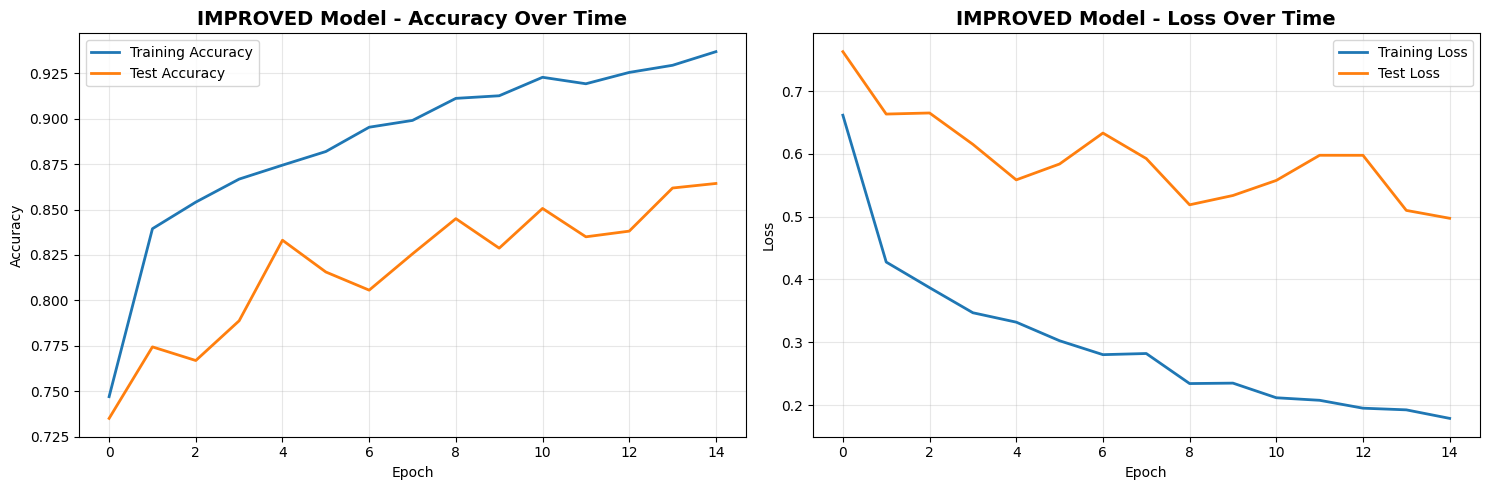


🎯 OLD MODEL: Test Accuracy = 78.06%
🎯 NEW MODEL: Test Accuracy = 86.44%
📈 Improvement: 8.38%


In [13]:
# Plot the improved model results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
ax1.plot(history_v2.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history_v2.history['val_accuracy'], label='Test Accuracy', linewidth=2)
ax1.set_title('IMPROVED Model - Accuracy Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history_v2.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history_v2.history['val_loss'], label='Test Loss', linewidth=2)
ax2.set_title('IMPROVED Model - Loss Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 OLD MODEL: Test Accuracy = 78.06%")
print(f"🎯 NEW MODEL: Test Accuracy = {history_v2.history['val_accuracy'][-1]*100:.2f}%")
print(f"📈 Improvement: {(history_v2.history['val_accuracy'][-1] - 0.7806)*100:.2f}%")

In [14]:
print(f"Training Accuracy: {history_v2.history['accuracy'][-1]*100:.2f}%")

Training Accuracy: 93.70%


In [15]:
# Unfreeze the last 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with VERY low learning rate
model_v2.compile(
    optimizer=Adam(learning_rate=0.00001),  # 100x smaller!
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🔧 Fine-tuning last 30 layers...")

# Train for just 5-10 more epochs
history_finetuned = model_v2.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"Final accuracy: {history_finetuned.history['val_accuracy'][-1]*100:.2f}%")

🔧 Fine-tuning last 30 layers...
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 216ms/step - accuracy: 0.7739 - loss: 0.8608 - val_accuracy: 0.8700 - val_loss: 0.5499 - learning_rate: 1.0000e-05
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 215ms/step - accuracy: 0.8637 - loss: 0.4399 - val_accuracy: 0.8731 - val_loss: 0.5994 - learning_rate: 1.0000e-05
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.8859 - loss: 0.3425 - val_accuracy: 0.8619 - val_loss: 0.6500 - learning_rate: 1.0000e-05
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - accuracy: 0.8882 - loss: 0.3133 - val_accuracy: 0.8700 - val_loss: 0.6699 - learning_rate: 1.0000e-05
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.9100 - loss: 0.2627 - val_accuracy: 0.8669 - val_loss: 0.6608 - learning_rate: 1.0000e-05
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.9145 - loss: 0.2477 - val_accuracy: 0.8681 - val_loss: 0.6336 - learning_rate: 1.0000e-05
Epoch 7/10
175

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("🔮 Generating predictions on all 1,600 test images...")

# Get predictions
test_generator.reset()  # Reset to start
predictions = model_v2.predict(test_generator, verbose=1)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels
true_classes = test_generator.classes

# Class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

print("✅ Predictions generated!")

🔮 Generating predictions on all 1,600 test images...
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step
✅ Predictions generated!


In [21]:
# After training, save the model
import joblib  # or pickle

# Save model
joblib.dump(model, 'my_model.pkl')

# Later, load it back
model = joblib.load('my_model.pkl')

In [22]:
# Save the trained model (new Keras format)
model.save('brain_tumor_model.keras')  # Or whatever name you want

print("Model saved successfully!")

Model saved successfully!


In [23]:
# NEW CONTEXT WINDOW OPENED


📊 GENERATING EVALUATION METRICS

🔍 Creating Confusion Matrix...


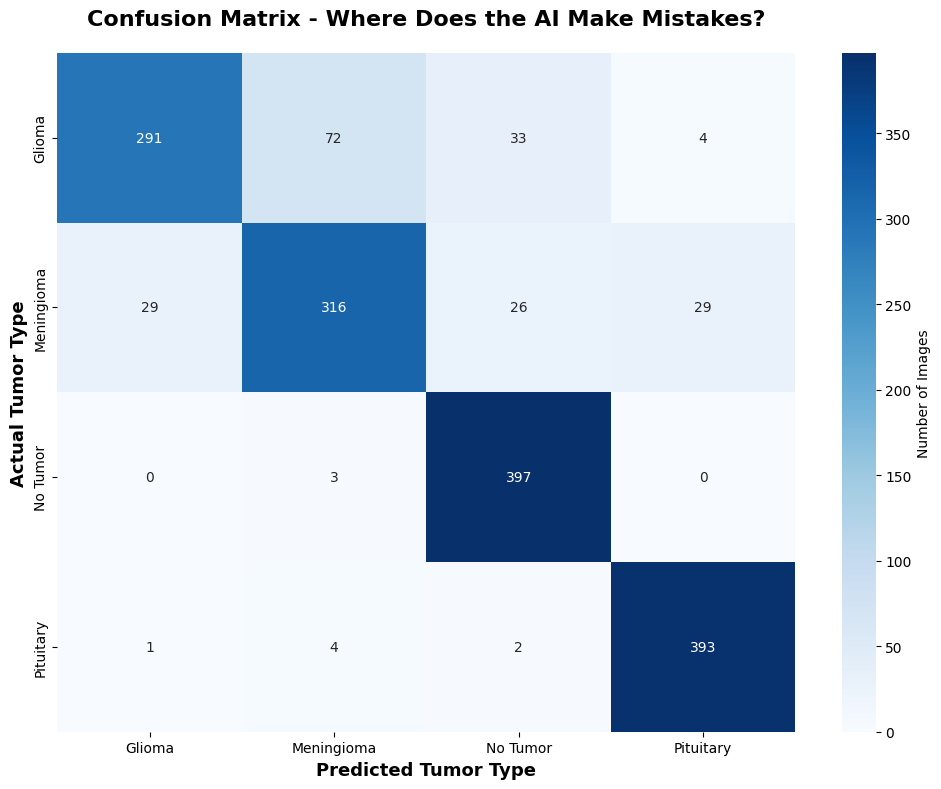

✅ Confusion Matrix created!

📈 Calculating per-class accuracy...

ACCURACY BY TUMOR TYPE
Glioma          → 72.75% correct
Meningioma      → 79.00% correct
No Tumor        → 99.25% correct
Pituitary       → 98.25% correct

📋 Generating detailed classification report...

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Glioma      0.907     0.728     0.807       400
  Meningioma      0.800     0.790     0.795       400
    No Tumor      0.867     0.993     0.925       400
   Pituitary      0.923     0.983     0.952       400

    accuracy                          0.873      1600
   macro avg      0.874     0.873     0.870      1600
weighted avg      0.874     0.873     0.870      1600


📊 Creating bar chart comparison...


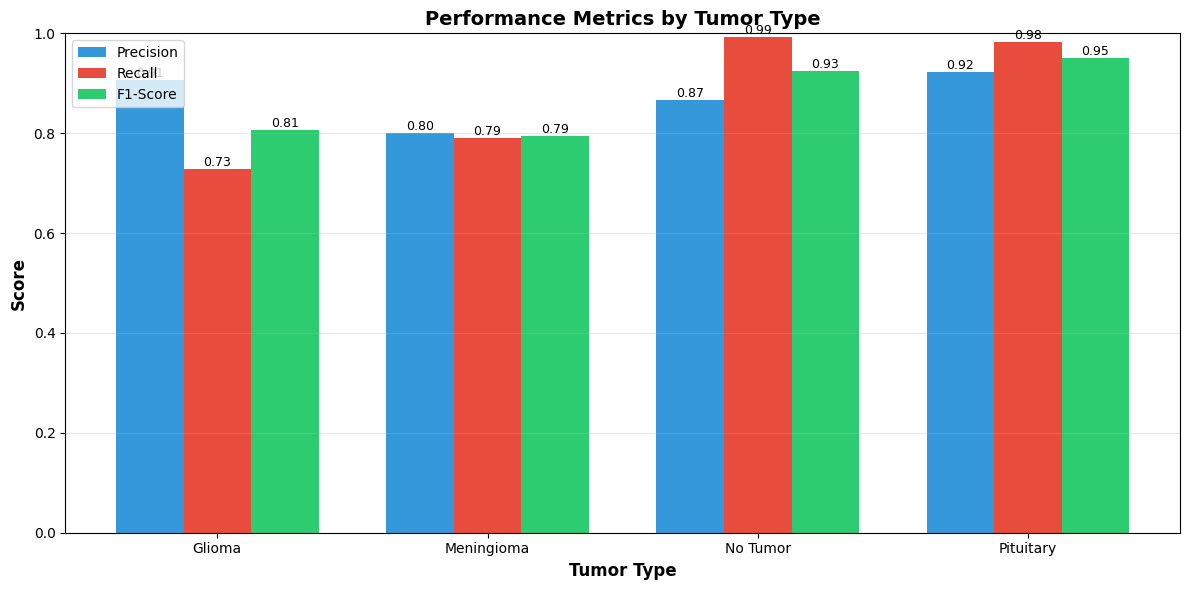


✅ All evaluation metrics generated!


In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("📊 GENERATING EVALUATION METRICS")
print("="*60)

# ============================================
# STEP 1: Create the Confusion Matrix
# ============================================
print("\n🔍 Creating Confusion Matrix...")

# This compares true_classes (actual labels) vs predicted_classes (AI's guesses)
cm = confusion_matrix(true_classes, predicted_classes)

# Visualize it as a heatmap (dark = many cases, light = few cases)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, 
            annot=True,           # Show numbers in each cell
            fmt='d',              # Format as integers (not decimals)
            cmap='Blues',         # Color scheme (darker = more cases)
            xticklabels=class_names,  # Label columns
            yticklabels=class_names,  # Label rows
            cbar_kws={'label': 'Number of Images'})

plt.title('Confusion Matrix - Where Does the AI Make Mistakes?', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Tumor Type', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Tumor Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Confusion Matrix created!")

# ============================================
# STEP 2: Calculate Per-Class Accuracy
# ============================================
print("\n📈 Calculating per-class accuracy...")

class_accuracies = cm.diagonal() / cm.sum(axis=1)  # Diagonal / Row sum

print("\n" + "="*60)
print("ACCURACY BY TUMOR TYPE")
print("="*60)
for i, class_name in enumerate(class_names):
    accuracy = class_accuracies[i] * 100
    print(f"{class_name:15} → {accuracy:.2f}% correct")

# ============================================
# STEP 3: Generate Classification Report
# ============================================
print("\n📋 Generating detailed classification report...")

# This gives precision, recall, F1-score for each class
report = classification_report(true_classes, 
                               predicted_classes, 
                               target_names=class_names,
                               digits=3)  # 3 decimal places

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(report)

# ============================================
# STEP 4: Visualize Precision, Recall, F1-Score
# ============================================
print("\n📊 Creating bar chart comparison...")

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    true_classes, 
    predicted_classes, 
    labels=[0, 1, 2, 3]
)

# Create grouped bar chart
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recall, width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#2ecc71')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Tumor Type', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics by Tumor Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ All evaluation metrics generated!")

🧠 BRAIN TUMOR PREDICTION TOOL - Single Image Testing

📦 Loading trained model...
✅ Model loaded successfully!

🔍 Loading image from: /Users/tayseerfarooq/Desktop/brain-tumour-ai/braincheck.jpg
🤖 Running prediction...


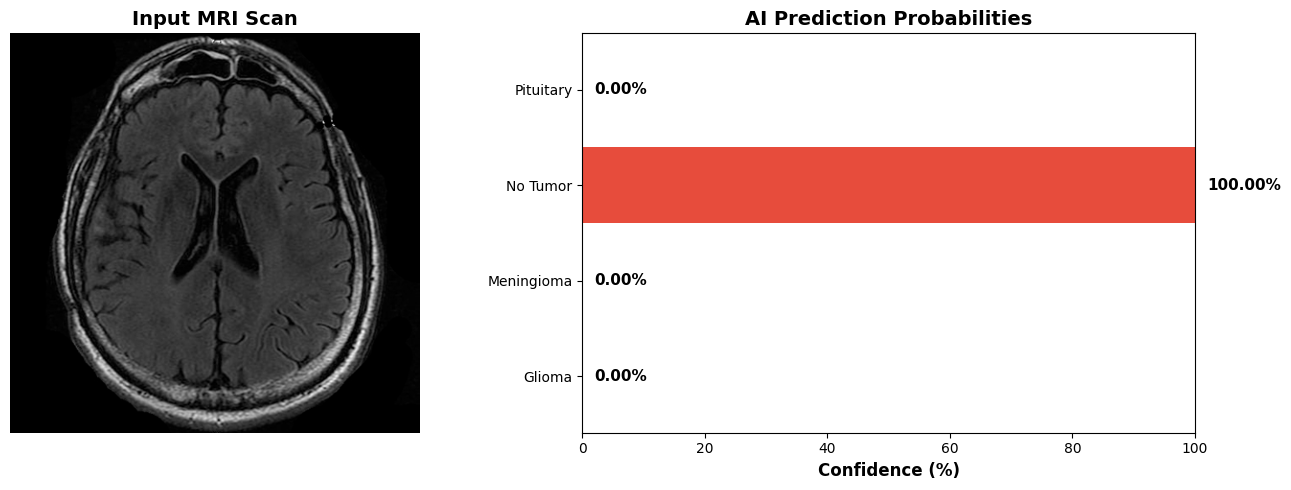


🎯 PREDICTION RESULTS
Predicted Class: No Tumor
Confidence: 100.00%

Full Breakdown:
   Glioma          →   0.00%
   Meningioma      →   0.00%
👉 No Tumor        → 100.00%
   Pituitary       →   0.00%


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import cv2

print("="*70)
print("🧠 BRAIN TUMOR PREDICTION TOOL - Single Image Testing")
print("="*70)

# Load the trained model
print("\n📦 Loading trained model...")
model_v2 = load_model('brain_tumor_model.keras')  # or 'best_model.h5' if that's what you saved
print("✅ Model loaded successfully!")

# Class names in correct order
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# ============================================
# REPLACE THIS PATH WITH YOUR UPLOADED IMAGE
# ============================================
img_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/braincheck.jpg'  # 👈 CHANGE THIS!

# Load and preprocess image
print(f"\n🔍 Loading image from: {img_path}")
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Get predictions
print("🤖 Running prediction...")
predictions = model_v2.predict(img_array, verbose=0)[0]

# ============================================
# VISUALIZE RESULTS
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Show MRI Image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
ax1.imshow(original_img)
ax1.axis('off')
ax1.set_title('Input MRI Scan', fontsize=14, fontweight='bold')

# RIGHT: Show Prediction Probabilities
colors = ['#e74c3c' if i == np.argmax(predictions) else '#3498db' 
          for i in range(len(predictions))]

bars = ax2.barh(class_names, predictions * 100, color=colors)
ax2.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
ax2.set_title('AI Prediction Probabilities', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 100])

# Add percentage labels
for bar, prob in zip(bars, predictions):
    width = bar.get_width()
    ax2.text(width + 2, bar.get_y() + bar.get_height()/2, 
            f'{prob*100:.2f}%', 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# PRINT DETAILED RESULTS
# ============================================
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print("\n" + "="*70)
print("🎯 PREDICTION RESULTS")
print("="*70)
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print("\nFull Breakdown:")
for i, class_name in enumerate(class_names):
    prob = predictions[i] * 100
    symbol = "👉" if i == np.argmax(predictions) else "  "
    print(f"{symbol} {class_name:15} → {prob:6.2f}%")
print("="*70)

🧠 BRAIN TUMOR PREDICTION TOOL - Single Image Testing

📦 Loading trained model...
✅ Model loaded successfully!

🔍 Loading image from: /Users/tayseerfarooq/Desktop/brain-tumour-ai/images-2.jpeg
🤖 Running prediction...


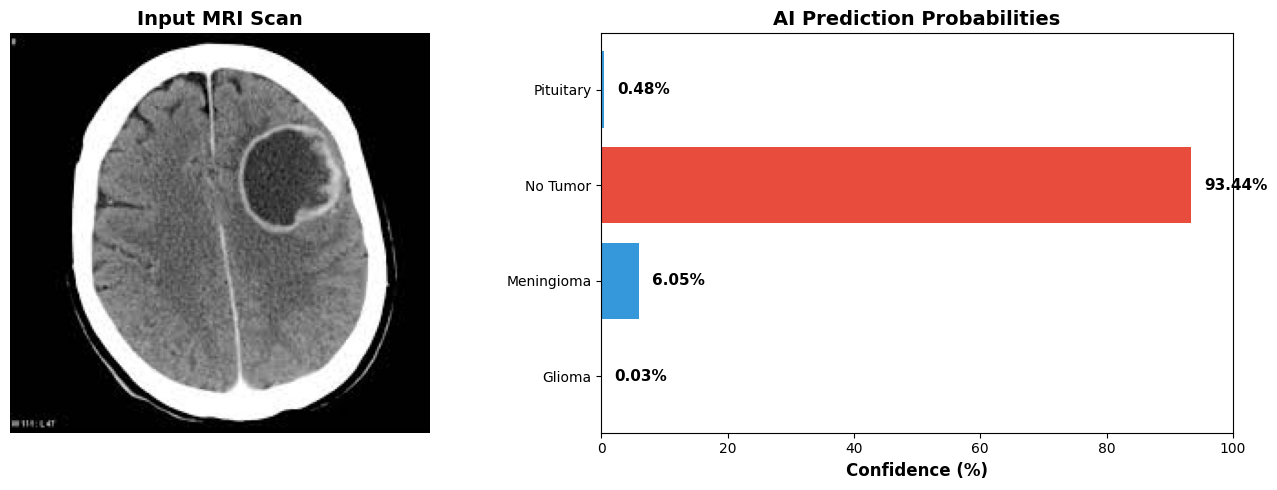


🎯 PREDICTION RESULTS
Predicted Class: No Tumor
Confidence: 93.44%

Full Breakdown:
   Glioma          →   0.03%
   Meningioma      →   6.05%
👉 No Tumor        →  93.44%
   Pituitary       →   0.48%


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import cv2

print("="*70)
print("🧠 BRAIN TUMOR PREDICTION TOOL - Single Image Testing")
print("="*70)

# Load the trained model
print("\n📦 Loading trained model...")
model_v2 = load_model('brain_tumor_model.keras')  # or 'best_model.h5' if that's what you saved
print("✅ Model loaded successfully!")

# Class names in correct order
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# ============================================
# REPLACE THIS PATH WITH YOUR UPLOADED IMAGE
# ============================================
img_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/mri_gbm3.jpg'  # 👈 CHANGE THIS!

# Load and preprocess image
print(f"\n🔍 Loading image from: {img_path}")
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Get predictions
print("🤖 Running prediction...")
predictions = model_v2.predict(img_array, verbose=0)[0]

# ============================================
# VISUALIZE RESULTS
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Show MRI Image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
ax1.imshow(original_img)
ax1.axis('off')
ax1.set_title('Input MRI Scan', fontsize=14, fontweight='bold')

# RIGHT: Show Prediction Probabilities
colors = ['#e74c3c' if i == np.argmax(predictions) else '#3498db' 
          for i in range(len(predictions))]

bars = ax2.barh(class_names, predictions * 100, color=colors)
ax2.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
ax2.set_title('AI Prediction Probabilities', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 100])

# Add percentage labels
for bar, prob in zip(bars, predictions):
    width = bar.get_width()
    ax2.text(width + 2, bar.get_y() + bar.get_height()/2, 
            f'{prob*100:.2f}%', 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# PRINT DETAILED RESULTS
# ============================================
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print("\n" + "="*70)
print("🎯 PREDICTION RESULTS")
print("="*70)
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print("\nFull Breakdown:")
for i, class_name in enumerate(class_names):
    prob = predictions[i] * 100
    symbol = "👉" if i == np.argmax(predictions) else "  "
    print(f"{symbol} {class_name:15} → {prob:6.2f}%")
print("="*70)

🧠 BRAIN TUMOR PREDICTION TOOL - Single Image Testing

📦 Loading trained model...
✅ Model loaded successfully!

🔍 Loading image from: /Users/tayseerfarooq/Desktop/brain-tumour-ai/mri_gbm3.jpg
🤖 Running prediction...


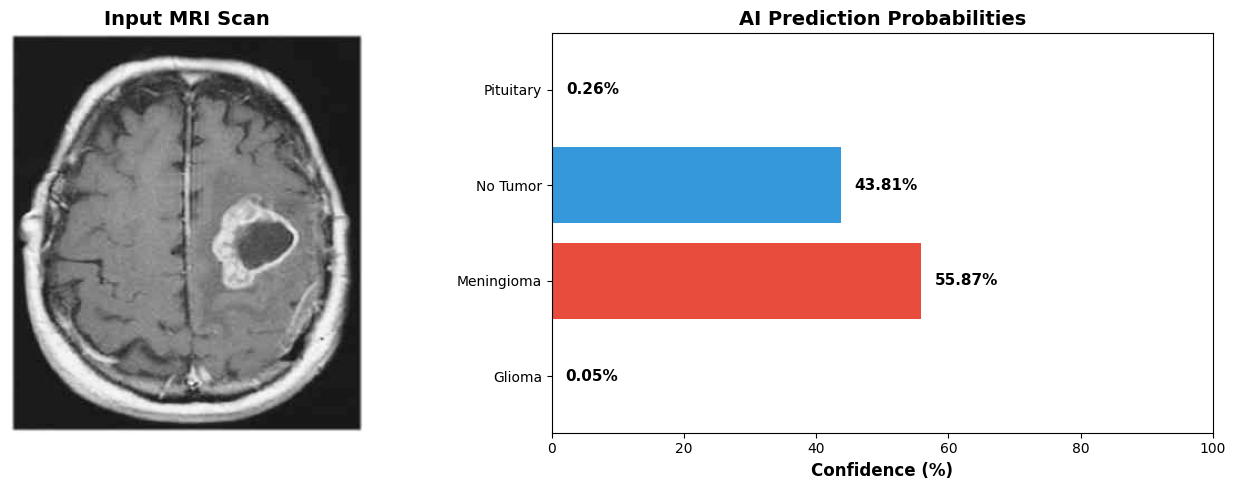


🎯 PREDICTION RESULTS
Predicted Class: Meningioma
Confidence: 55.87%

Full Breakdown:
   Glioma          →   0.05%
👉 Meningioma      →  55.87%
   No Tumor        →  43.81%
   Pituitary       →   0.26%


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import cv2

print("="*70)
print("🧠 BRAIN TUMOR PREDICTION TOOL - Single Image Testing")
print("="*70)

# Load the trained model
print("\n📦 Loading trained model...")
model_v2 = load_model('brain_tumor_model.keras')  # or 'best_model.h5' if that's what you saved
print("✅ Model loaded successfully!")

# Class names in correct order
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# ============================================
# REPLACE THIS PATH WITH YOUR UPLOADED IMAGE
# ============================================
img_path = '/Users/tayseerfarooq/Desktop/brain-tumour-ai/mri_gbm3.jpg'  # 👈 CHANGE THIS!

# Load and preprocess image
print(f"\n🔍 Loading image from: {img_path}")
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Get predictions
print("🤖 Running prediction...")
predictions = model_v2.predict(img_array, verbose=0)[0]

# ============================================
# VISUALIZE RESULTS
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Show MRI Image
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
ax1.imshow(original_img)
ax1.axis('off')
ax1.set_title('Input MRI Scan', fontsize=14, fontweight='bold')

# RIGHT: Show Prediction Probabilities
colors = ['#e74c3c' if i == np.argmax(predictions) else '#3498db' 
          for i in range(len(predictions))]

bars = ax2.barh(class_names, predictions * 100, color=colors)
ax2.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
ax2.set_title('AI Prediction Probabilities', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 100])

# Add percentage labels
for bar, prob in zip(bars, predictions):
    width = bar.get_width()
    ax2.text(width + 2, bar.get_y() + bar.get_height()/2, 
            f'{prob*100:.2f}%', 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# PRINT DETAILED RESULTS
# ============================================
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print("\n" + "="*70)
print("🎯 PREDICTION RESULTS")
print("="*70)
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print("\nFull Breakdown:")
for i, class_name in enumerate(class_names):
    prob = predictions[i] * 100
    symbol = "👉" if i == np.argmax(predictions) else "  "
    print(f"{symbol} {class_name:15} → {prob:6.2f}%")
print("="*70)